# Reason, Retrieve, Reason Loop

From static RAG to agentic retrieval using LangChain + LangGraph.


LangChain / LangGraph primitives we will use in this demonstration

| Primitive | What it is | Why it is here |
|-----------|-----------|----------------|
| `init_chat_model` | LangChain's provider-agnostic LLM factory | One-line provider swap (Gemini / OpenAI / Anthropic / Ollama) |
| `init_embeddings` | Same idea for embedders | Keep retrieval provider-agnostic too |
| `InMemoryVectorStore` | Tiny LangChain vector store, no deps | Demo-grade retrieval; we will swap to Chroma in a later cell |
| `Chroma` | Persistent disk-backed vector DB | Production-shaped retrieval the agent loop is identical against |
| `StateGraph` | LangGraph state-machine container | The reason-retrieve-reason loop is a graph |
| `with_structured_output(Pydantic)` | LLM output validated to a schema | The schema is the loop's control flow |


`init_chat_model` / `init_embeddings` make the LLM and embedder swappable in one line. We will use Gemini as default, but the same  pipeline can be used with OpenAI/Anthropic/Llama

We are going to use the `InMemoryVectorStore` here. For production, you would swap to Chroma (single-machine, persistent) or FAISS (CPU-fast, batch-friendly) or a managed service (Pinecone / Weaviate), as we already know.

## Setup, corpus, and retrieval

In [19]:
# !pip install -q langchain langchain-google-genai langchain-openai langgraph langchain-community

In [20]:
from langchain.chat_models import init_chat_model
from langchain.embeddings import init_embeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Optional, Literal
from pydantic import BaseModel, Field
import os, json

Let's first define the LLM and embedding models with LangChain

In [21]:
# Keep the API keys for the models of choice in the loaded env file
from dotenv import load_dotenv
load_dotenv()

# os.environ['GEMINI_API_KEY']  # the variable for API key

llm   = init_chat_model('gemini-3.5-flash-lite', model_provider='google_genai', temperature=0)
embed = init_embeddings('sentence-transformers/all-MiniLM-L6-v2', provider='huggingface')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Let's create a sample corpus for retrieval. The corpus is deliberately engineered such that `Q_REASON` requires chaining multiple retrievals. No single chunk contains the full answer.

This is what breaks top-k based retrieval

In [22]:
# Demo corpus
corpus = [
    Document(page_content='Project Atlas is the internal codename for our 2024 logistics platform overhaul. It was officially launched in Q1 2024.', metadata={'id': 'd1'}),
    Document(page_content='Project Atlas is led by Priya Shah, who joined the company in 2019 and previously led the warehouse automation initiative.', metadata={'id': 'd2'}),
    Document(page_content='Priya Shah reports directly to Arjun Mehta, the VP of Engineering who also oversees the infrastructure and platform orgs.', metadata={'id': 'd3'}),
    Document(page_content='Arjun Mehta is the executive sponsor of the Agentic Systems roadmap, which defines the next three years of AI investment.', metadata={'id': 'd4'}),
    Document(page_content='The Agentic Systems roadmap prioritizes retrieval-augmented reasoning, tool-using agents, and memory-persistent workflows.', metadata={'id': 'd5'}),
    Document(page_content='Project Atlas uses a Postgres-backed event log and a Kafka stream for warehouse telemetry across 14 regional hubs.', metadata={'id': 'd6'}),
    Document(page_content='The warehouse automation initiative that Priya Shah previously led cut order-to-ship latency by 38 percent in 2021.', metadata={'id': 'd7'}),
    Document(page_content='Arjun Mehta joined the company in 2016 and was promoted to VP of Engineering in 2022 after the platform reorg.', metadata={'id': 'd8'}),
    Document(page_content='The Agentic Systems roadmap was ratified by the executive committee in late 2023 and funded through 2027.', metadata={'id': 'd9'}),
    Document(page_content='Project Atlas publishes a monthly metrics report covering uptime, order throughput, and customer complaints.', metadata={'id': 'd10'}),
]


`retrieve()` is the same function both the static retrieval baseline and the loop call: that isolation is what lets us attribute the accuracy delta purely to the control flow.

In [23]:
# Build the vector store
vectorstore = InMemoryVectorStore.from_documents(corpus, embed)

def retrieve(query: str, k: int = 3) -> List[Document]:
    """Top-k similarity retrieval. 
    This is the same primitive both the static baseline and the agentic loop call
    The difference is WHO decides the query, not HOW retrieval works."""

    return vectorstore.similarity_search(query, k=k)

As an exercise, replace the in-memory vectore store with a proper vectorDB like Chroma and use it as a retriever

In [24]:
# Two questions engineered to show the gap:
# - Q_LOOKUP: single fact in one chunk -- static RAG should handle it.
# - Q_REASON: requires chaining Atlas -> Priya -> Arjun -> roadmap.

Q_LOOKUP = 'When was Project Atlas launched?'
Q_REASON = 'Who sponsors the roadmap that the leader of Project Atlas ultimately reports into, and what does that roadmap prioritize?'

print('Corpus size:', len(corpus))
print('Q_LOOKUP:', Q_LOOKUP)
print('Q_REASON:', Q_REASON)

Corpus size: 10
Q_LOOKUP: When was Project Atlas launched?
Q_REASON: Who sponsors the roadmap that the leader of Project Atlas ultimately reports into, and what does that roadmap prioritize?


Let's start with a basic RAG pipeline. We will see its limitations and then move on to reasoning-driven retrieval. We will run the simplest possible RAG (one retrieval, one generation) on a multi-hop reasoning question to see its performance.

The failure mode we will observe: the question vector lands near the *first hop* but not near the *answer chunk*, so the LLM either says "INSUFFICIENT EVIDENCE" or fabricates the second hop

## Static RAG baseline

- Define `static_rag(question, k)`: one retrieval, one generation. No feedback loop.
- Run it on `Q_REASON` and prints the retrieved doc ids plus the (likely incomplete) answer.


This is the general shape of a first-draft RAG system. The retrieval query is the raw user question. 

The embedding of "Who sponsors the roadmap..." should be pulled toward *d1*/*d2*/*d10*, and miss *d3*/*d4*/*d5*, the chunks that actually complete the chain.

So, if retrieved ids do NOT include all of *d2, d3, d4, d5*, we will encounter the failure. Let's start with the basic pipeline.

In [25]:
def format_context(docs: List[Document]) -> str:
    """Serialize retrieved docs into a numbered context block"""
    return '\n'.join(f"[{d.metadata['id']}] {d.page_content}" for d in docs)

In [26]:
# Pattern: retrieve(question, k) -> stuff context into prompt -> LLM
# There is NO feedback from reasoning back into retrieval

def static_rag(question: str, k: int = 3) -> dict:
    """Classic one-shot RAG: one retrieval, one generation
    The LLM only sees the chunks that the INITIAL query embedding was close to
    It cannot request more evidence even when it realizes the context is insufficient."""

    docs = retrieve(question, k=k)
    context = format_context(docs)

    prompt = (
        'Answer the question using ONLY the context below. '
        'If the context is insufficient, say so briefly.\n\n'
        f'Context:\n{context}\n\nQuestion: {question}\nAnswer:'
    )
    print("()()()()()()()()()()()()()()()()()()()()()()()()")
    print(prompt)
    print("()()()()()()()()()()()()()()()()()()()()()()()()")
    
    answer = llm.invoke(prompt).content
    return {'question': question, 'docs': [d.metadata['id'] for d in docs], 'answer': answer}

In [27]:
# Testing with a straight lookup question

lookup = static_rag(Q_LOOKUP)
print('Retrieved:', lookup['docs'])
print('Answer:\n', lookup['answer'])

()()()()()()()()()()()()()()()()()()()()()()()()
Answer the question using ONLY the context below. If the context is insufficient, say so briefly.

Context:
[d1] Project Atlas is the internal codename for our 2024 logistics platform overhaul. It was officially launched in Q1 2024.
[d2] Project Atlas is led by Priya Shah, who joined the company in 2019 and previously led the warehouse automation initiative.
[d6] Project Atlas uses a Postgres-backed event log and a Kafka stream for warehouse telemetry across 14 regional hubs.

Question: When was Project Atlas launched?
Answer:
()()()()()()()()()()()()()()()()()()()()()()()()


/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Retrieved: ['d1', 'd2', 'd6']
Answer:
 [{'type': 'text', 'text': 'Project Atlas was officially launched in Q1 2024.', 'extras': {'signature': 'El4KXAERTTIPqkk+HLjNZfSocACwjr+P1L46DvLLl/qek2MPAj3DqHwF++i9G9dNa2Ii3MYl2pmwNKM7Vb/RL6P5xVdjgvZTpWgklx+K4r5jkXaINVKIYHXArftlL4T6'}}]


In [8]:
# Run on the multi-hop question (we are expecting an incomplete or hedged answer)
# because the retrieval for the FULL question does not surface d3/d4/d5

baseline = static_rag(Q_REASON)
print('Retrieved:', baseline['docs'])
print('Answer:\n', baseline['answer'])

Retrieved: ['d2', 'd1', 'd9']
Answer:
 The context is insufficient to answer who sponsors the roadmap that the leader of Project Atlas ultimately reports into, or what that roadmap prioritizes. While an "Agentic Systems roadmap" is mentioned as being ratified by the executive committee, there is no information linking Project Atlas or its leader to this specific roadmap, nor what it prioritizes.


So while our basic RAG system is able to retrieve correctly for a simple lookup question, it did not find relevant evidence for harder reasoning based question

## Reason-Retrieve-Reason loop

- Define a pydantic `ReasonDecision` schema so the LLM's branch decision is machine-readable
- Define a typed `LoopState` (question, evidence, seen_ids, iteration, next_query, status, answer, trace)
- Implement two nodes: `retrieve_node` (similarity search + dedupe) and `reason_node` (structured-output LLM call)
- Wire them into a `StateGraph` with a conditional edge: `status == 'answer'` ends, otherwise loops back to retrieve

In [34]:
# Define a Pydantic schema and use it with the `.with_structured_output()` method

class ReasonDecision(BaseModel):
    """Structured output schema
    Using with_structured_output makes the LLM's decision MACHINE-READABLE, which is what lets us wire it directly into a conditional edge instead of parsing free text."""

    status: Literal['answer', 'need_more'] = Field(description='answer if evidence is sufficient, else need_more')
    
    next_query: Optional[str] = Field(default=None, description='A targeted retrieval query when status=need_more')
    
    answer: Optional[str] = Field(default=None, description='Final answer when status=answer')

structured_llm = llm.with_structured_output(ReasonDecision)

`with_structured_output(ReasonDecision)` eliminates JSON parsing, and `status` can be inspected directly

In [35]:
class LoopState(TypedDict):
    question: str
    evidence: List[Document]   # accumulated across iterations
    seen_ids: List[str]        # deduplicate so we do not re-add the same chunks
    iteration: int             # hard cap guard
    next_query: str            # the query to run next (starts = question)
    status: str                # 'answer' | 'need_more' | 'start'
    answer: str
    trace: List[dict]          # audit log for teaching visibility

Deduping by `metadata.id` prevents the loop from stalling on the same chunk every iteration. `trace` is a first-class field so debugging reads the same audit log the runtime does.

In [36]:
def retrieve_node(state: LoopState) -> dict:

    """Run similarity search on state['next_query'] and merge NEW hits into accumulated evidence.
    Without dedupe with docID, the loop re-fetches the same top-1 chunk every iteration and stalls."""

    q = state['next_query']

    hits = retrieve(q, k=3)
    seen = set(state['seen_ids'])
    new_hits = [d for d in hits if d.metadata['id'] not in seen]

    evidence = state['evidence'] + new_hits
    seen_ids = state['seen_ids'] + [d.metadata['id'] for d in new_hits]
    
    trace = state['trace'] + [{
        'iter': state['iteration'], 'query': q,
        'new_hits': [d.metadata['id'] for d in new_hits],
    }]
    return {'evidence': evidence, 'seen_ids': seen_ids, 'trace': trace}

In [37]:
MAX_ITERS = 3   # Set a step cap of 3 iterations inside `reason_node`

# define a reason prompt for the agent
REASON_PROMPT = """
    You are an agentic retriever. Given the question and the evidence gathered so far, 
    decide: do you have enough to answer? 
    - If yes, set status='answer' and fill `answer`. 
    - If not, set status='need_more' and propose ONE targeted follow-up query that would fill the gap.
    \n Do NOT ask for the whole question again ask for the missing fact.\n\n
    Question: {q}\n\nEvidence so far:\n{ctx}\n
"""
    
def reason_node(state: LoopState) -> dict:

    """Call the LLM with structured output. 
    The pydantic schema forces a clean branch decision"""

    it = state['iteration'] + 1
    ctx = '\n'.join(f"[{d.metadata['id']}] {d.page_content}" for d in state['evidence']) or '(none)'

    # Force termination at the cap even if the model still wants more.
    if it >= MAX_ITERS:
        decision = structured_llm.invoke(
            REASON_PROMPT.format(q=state['question'], ctx=ctx) + '\nYou have reached the retrieval budget. status MUST be answer.'
            )
        
        status, nq, ans = 'answer', None, (decision.answer or 'Unable to answer within budget.')

    else:
        decision = structured_llm.invoke(REASON_PROMPT.format(q=state['question'], ctx=ctx))
        status = decision.status
        nq = decision.next_query
        ans = decision.answer or ''
    
    trace = state['trace'] + [{'iter': it, 'decision': status, 'next_query': nq}]
    
    return {'iteration': it, 'status': status, 'next_query': nq or '', 'answer': ans, 'trace': trace}

In [39]:
def should_continue(state: LoopState) -> str:
    """Conditional edge: route back to retrieve if the model asked for more,
    otherwise END. This tiny function is the entire agentic control flow."""
    return END if state['status'] == 'answer' else 'retrieve'

`['retrieve', 'reason']` (plus start/end) confirms that the graph compiled with both nodes

In [40]:
# Adding the state graph

graph = StateGraph(LoopState)
graph.add_node('retrieve', retrieve_node)
graph.add_node('reason', reason_node)
graph.set_entry_point('retrieve')
graph.add_edge('retrieve', 'reason')
graph.add_conditional_edges('reason', should_continue, {'retrieve': 'retrieve', END: END})
app = graph.compile()
print('Graph compiled:', list(app.get_graph().nodes))

Graph compiled: ['__start__', 'retrieve', 'reason', '__end__']


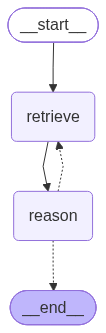

In [41]:
app

## Run the loop and read the trace

Finally, initialise the loop state, invoke the compiled graph on `Q_REASON`, and print the full step-by-step trace plus the final answer and the set of evidence doc ids that ended up in the prompt.

Note: Priming `next_query` with the raw question makes iteration 1 identical to static RAG. All downstream benefit comes from iteration 2+, where the LLM writes a NEW targeted query.

In [ ]:
# Run the loop on the multi-hop question and print the full trace
# Each trace entry shows either a retrieval step (new_hits) or a reasoning step (decision + next_query)
# Reading it top-to-bottom reveals how the agent bridges Atlas -> Priya -> Arjun -> roadmap

def run_loop(question: str) -> dict:

    initial: LoopState = {
        'question': question,
        'evidence': [], 'seen_ids': [],
        'iteration': 0, 'next_query': question,
        'status': 'start', 'answer': '', 'trace': [],
    }
    final = app.invoke(initial)
    
    return final

result = run_loop(Q_REASON)

print('=== TRACE ===')
for step in result['trace']:
    print(json.dumps(step, indent=2))

print('\n=== FINAL ANSWER ===')
print(result['answer'])

print('\n=== EVIDENCE IDS ===')
print([d.metadata['id'] for d in result['evidence']])

/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


## Tips and common pitfalls

### Adopting LangGraph in production

- Always set `recursion_limit`. The default is 25 for `StateGraph.invoke` but unbounded recursion is the #1 production agent failure. Set it explicitly per-graph and never higher than your cost budget allows.
- Swap `InMemorySaver` with a vectorDB before deployment The interface is identical. Loss of state on restart is a development convenience, not a production property.
- Visualise the graph. `graph.get_graph().draw_mermaid_png()` exports a PNG you can paste into a doc or PR. This catches misrouted edges instantly.
- Set `temperature=0.0` on every `with_structured_output` step. Higher temperature increases the rate of malformed Pydantic responses.

### Common pitfalls in reason-retrieve loops
- `seen_ids` is per-thread, not global. A new thread starts the loop fresh.
- Reformulated `next_query` strings can drift off-corpus. If the LLM invents queries about entities that do not exist in your corpus, retrieval returns garbage and the next iteration wastes a turn. <br>
    Mitigation: prefix the reasoning prompt with a short corpus summary so the model knows the entity vocabulary.
- Cap iterations before you deploy
